Customer Churn Prediction
Machine Learning Project
Project Overview

Customer churn occurs when a customer stops using a company's products or services. Predicting customer churn can help businesses identify customers who may leave and take appropriate actions to retain them.

In this project, machine learning techniques are used to predict whether a customer is likely to churn based on customer demographics, services, contract details, tenure, and billing information.

Project Objectives

Understand and explore the customer churn dataset.

Clean and prepare the data for machine learning.

Analyze factors associated with customer churn.

Create useful features for prediction.

Train and compare different classification models.

Evaluate the models using appropriate performance metrics.

Select and analyze the best-performing model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)


1. Loading the Dataset

Before performing any preprocessing, the dataset is loaded and inspected to understand its structure and the information available for predicting customer churn.

In [3]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")

df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Initial Dataset Inspection

The first step in understanding a dataset is to check its dimensions. This helps us determine how many customer records and features are available.

In [4]:
df.shape


(7043, 21)

In [5]:
df.columns


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Understanding the Dataset

Next, we examine the data types of the variables. This is important because numerical and categorical variables require different preprocessing techniques before they can be used by machine learning models.

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


2. Data Quality Check

Before cleaning the dataset, we check for missing values and duplicate records. This helps identify potential data quality issues that could affect the machine learning models.

In [7]:
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.duplicated().sum()


np.int64(0)

Investigating TotalCharges

The TotalCharges column represents the total amount charged to a customer. Although it contains numerical values, it is currently stored as a text column. We will convert it to a numeric format and check whether any values become missing during the conversion.

In [9]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"].isnull().sum()


np.int64(11)

In [10]:
df[df["TotalCharges"].isnull()][
    ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]


,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


3. Data Cleaning

The TotalCharges column was originally stored as text, so it was converted to a numeric format. This conversion revealed 11 missing values. These records all have a tenure of zero, so their total charges can reasonably be treated as zero.

The customerID column is also removed because it is an identifier and does not provide useful predictive information.

In [11]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

df = df.drop(columns=["customerID"])

print("Missing values after cleaning:")
print(df.isnull().sum().sum())

print("\nDataset shape:", df.shape)


Missing values after cleaning:
0

Dataset shape: (7043, 20)


4. Feature Engineering

Feature engineering involves creating additional variables that may help the machine learning models identify patterns in customer behavior.

Three features are created:

AverageMonthlySpend: estimated average monthly spending based on total charges and tenure.

ServiceCount: number of additional services subscribed to by the customer.

TenureGroup: groups customers according to their length of relationship with the company.

In [12]:
df["AverageMonthlySpend"] = (
    df["TotalCharges"] /
    df["tenure"].replace(0, np.nan)
)

df["AverageMonthlySpend"] = df["AverageMonthlySpend"].fillna(0)

service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["ServiceCount"] = (
    df[service_columns] == "Yes"
).sum(axis=1)

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 100],
    labels=["0-1 Year", "1-2 Years", "2-4 Years", "4+ Years"]
)

df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AverageMonthlySpend,ServiceCount,TenureGroup
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,29.850000,1,0-1 Year
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,0,55.573529,2,2-4 Years
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,54.075000,2,0-1 Year
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,40.905556,3,2-4 Years
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,75.825000,0,0-1 Year


5. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is used to understand the distribution of the target variable and identify patterns that may be related to customer churn.

In [13]:
churn_counts = df["Churn"].value_counts()

print(churn_counts)

print("\nChurn percentage:")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))


Churn
0    5174
1    1869
Name: count, dtype: int64

Churn percentage:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


Churn Distribution

The distribution of the target variable is visualized to understand the proportion of customers who stayed with the company compared with those who churned.

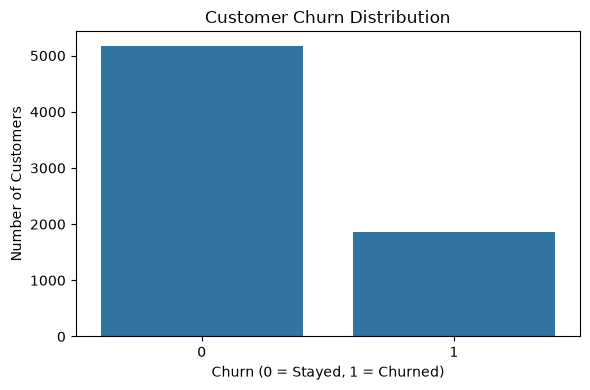

In [14]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = Stayed, 1 = Churned)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


Contract Type and Churn

Contract type may influence customer retention. Customers with longer-term contracts may behave differently from customers using month-to-month contracts.

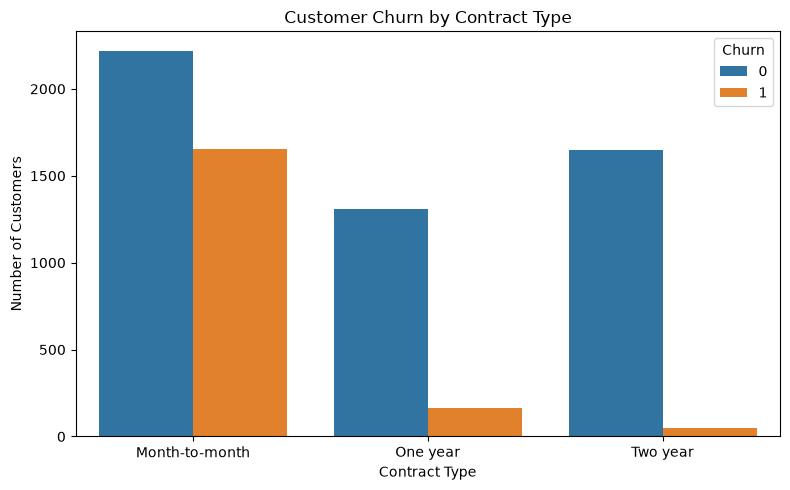

In [15]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


Monthly Charges and Churn

Monthly charges are compared between customers who stayed and customers who churned. This helps us investigate whether spending levels are associated with churn.

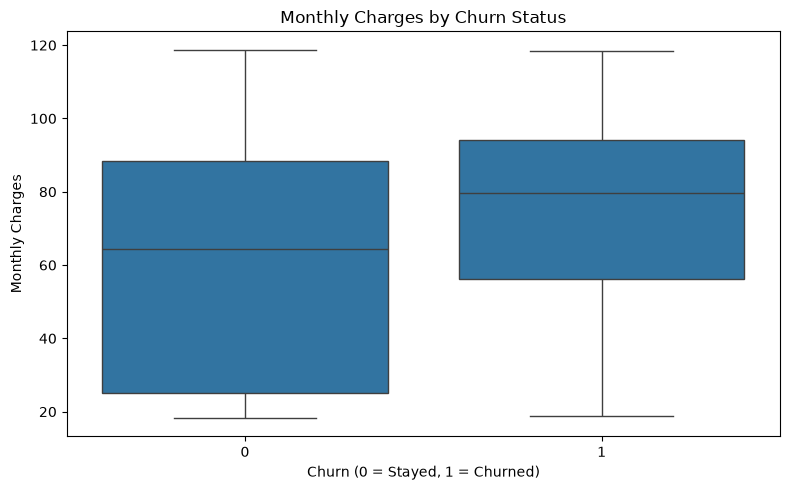

In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn (0 = Stayed, 1 = Churned)")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()


Tenure and Churn

Customer tenure represents how long a customer has been with the company. Examining tenure alongside churn can help identify whether newer or longer-term customers are more likely to leave.

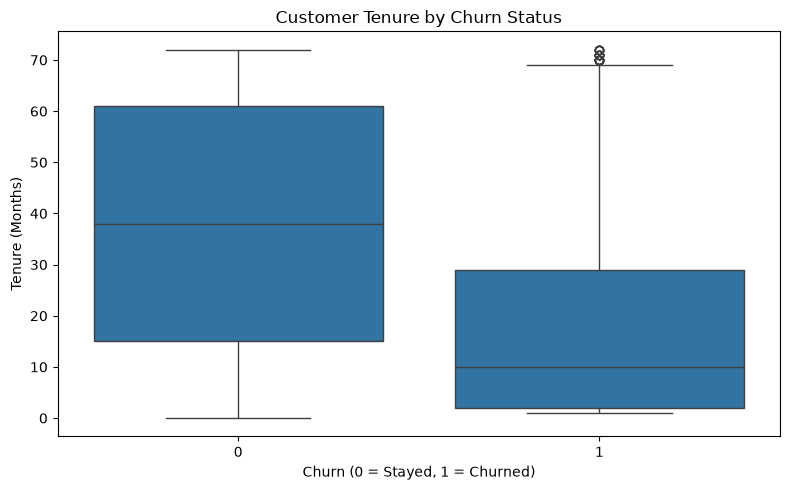

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn (0 = Stayed, 1 = Churned)")
plt.ylabel("Tenure (Months)")

plt.tight_layout()
plt.show()


6. Preparing Data for Machine Learning

The target variable is Churn, where 0 represents customers who stayed and 1 represents customers who churned.

The remaining columns will be used as input features. The data will then be divided into training and testing sets so that the models can be evaluated on customers they have not seen during training.

In [18]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 5634
Testing samples: 1409


Identifying Feature Types

The dataset contains both numerical and categorical variables. Numerical variables will be scaled, while categorical variables will be converted into numerical form using one-hot encoding.

In [19]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


Numeric features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AverageMonthlySpend', 'ServiceCount']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']


Data Preprocessing

Machine learning models require numerical input. Therefore, numerical variables are standardized and categorical variables are converted into numerical features using one-hot encoding.

A preprocessing pipeline is used so that the same transformations are applied consistently to both training and testing data.

In [20]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])


7. Logistic Regression

Logistic Regression is used as the baseline classification model. It is a simple and interpretable algorithm that is suitable for binary classification problems such as customer churn prediction.

In [21]:
logistic_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print("Accuracy:", round(
    accuracy_score(y_test, logistic_predictions), 4
))
print("Precision:", round(
    precision_score(y_test, logistic_predictions), 4
))
print("Recall:", round(
    recall_score(y_test, logistic_predictions), 4
))
print("F1 Score:", round(
    f1_score(y_test, logistic_predictions), 4
))
print("ROC-AUC:", round(
    roc_auc_score(y_test, logistic_probabilities), 4
))


Logistic Regression
Accuracy: 0.7331
Precision: 0.4983
Recall: 0.7914
F1 Score: 0.6116
ROC-AUC: 0.8419


8. Random Forest

Random Forest is a tree-based ensemble algorithm that can capture non-linear relationships between customer characteristics and churn. It is compared with Logistic Regression to determine whether a more flexible model can improve prediction performance.

In [22]:
random_forest_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_test)
rf_probabilities = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest")
print("Accuracy:", round(
    accuracy_score(y_test, rf_predictions), 4
))
print("Precision:", round(
    precision_score(y_test, rf_predictions), 4
))
print("Recall:", round(
    recall_score(y_test, rf_predictions), 4
))
print("F1 Score:", round(
    f1_score(y_test, rf_predictions), 4
))
print("ROC-AUC:", round(
    roc_auc_score(y_test, rf_probabilities), 4
))


Random Forest
Accuracy: 0.7594
Precision: 0.5323
Recall: 0.7701
F1 Score: 0.6295
ROC-AUC: 0.8404


9. XGBoost

XGBoost is another tree-based ensemble method. It builds models sequentially, with each new tree attempting to improve the errors made by previous trees. It is included to compare another powerful approach for customer churn prediction.

In [23]:
xgb_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)
xgb_probabilities = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost")
print("Accuracy:", round(
    accuracy_score(y_test, xgb_predictions), 4
))
print("Precision:", round(
    precision_score(y_test, xgb_predictions), 4
))
print("Recall:", round(
    recall_score(y_test, xgb_predictions), 4
))
print("F1 Score:", round(
    f1_score(y_test, xgb_predictions), 4
))
print("ROC-AUC:", round(
    roc_auc_score(y_test, xgb_probabilities), 4
))


XGBoost
Accuracy: 0.802
Precision: 0.6632
Recall: 0.516
F1 Score: 0.5805
ROC-AUC: 0.8425


10. Model Comparison

The three models show different strengths. XGBoost achieved the highest accuracy and ROC-AUC, while Logistic Regression achieved the highest recall. Random Forest produced the highest F1-score.

Since customer churn prediction is focused on identifying customers who may leave, accuracy alone is not sufficient for selecting a model. Recall and F1-score are also important because missing a potential churner can reduce the effectiveness of customer retention efforts.

In [24]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, logistic_predictions),
        accuracy_score(y_test, rf_predictions),
        accuracy_score(y_test, xgb_predictions)
    ],
    "Precision": [
        precision_score(y_test, logistic_predictions),
        precision_score(y_test, rf_predictions),
        precision_score(y_test, xgb_predictions)
    ],
    "Recall": [
        recall_score(y_test, logistic_predictions),
        recall_score(y_test, rf_predictions),
        recall_score(y_test, xgb_predictions)
    ],
    "F1 Score": [
        f1_score(y_test, logistic_predictions),
        f1_score(y_test, rf_predictions),
        f1_score(y_test, xgb_predictions)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, logistic_probabilities),
        roc_auc_score(y_test, rf_probabilities),
        roc_auc_score(y_test, xgb_probabilities)
    ]
})

results.round(4)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7331,0.4983,0.7914,0.6116,0.8419
1,Random Forest,0.7594,0.5323,0.7701,0.6295,0.8404
2,XGBoost,0.8020,0.6632,0.5160,0.5805,0.8425


11. Final Model Selection

Based on the initial comparison, Random Forest is selected for further analysis because it achieved the highest F1-score while maintaining a strong recall. Although XGBoost achieved slightly higher accuracy and ROC-AUC, its recall was considerably lower.

For a churn prediction problem, identifying customers who are likely to leave is important, so the balance between precision and recall is considered when selecting the final model.

In [25]:
final_model = random_forest_model

final_probabilities = final_model.predict_proba(X_test)[:, 1]

final_predictions = (
    final_probabilities >= 0.50
).astype(int)

print(classification_report(
    y_test,
    final_predictions,
    target_names=["Stayed", "Churned"]
))


              precision    recall  f1-score   support

      Stayed       0.90      0.76      0.82      1035
     Churned       0.53      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



12. Confusion Matrix

The confusion matrix shows how many customers were correctly and incorrectly classified as stayed or churned. It helps us understand the types of prediction errors made by the final model.

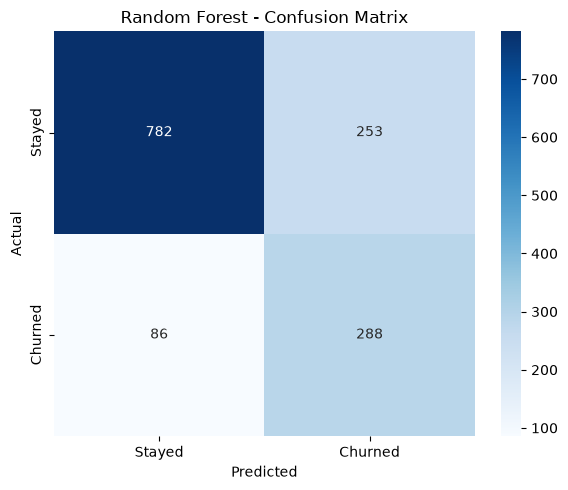

In [26]:
cm = confusion_matrix(
    y_test,
    final_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()


13. ROC Curve

The ROC curve evaluates how well the model distinguishes between customers who churn and customers who stay across different classification thresholds. The ROC-AUC score summarizes this performance, with higher values indicating better discrimination.

<Figure size 700x500 with 0 Axes>

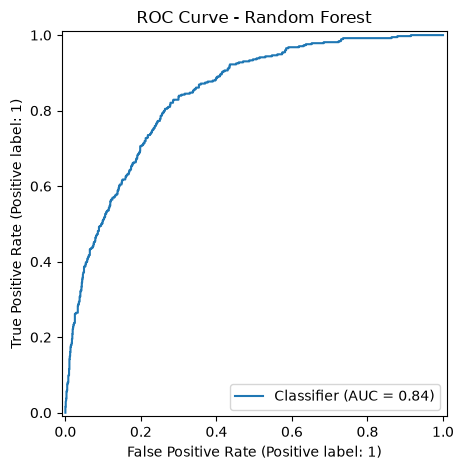

In [27]:
plt.figure(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test,
    final_probabilities
)

plt.title("ROC Curve - Random Forest")
plt.tight_layout()
plt.show()


14. Precision-Recall Curve

The precision-recall curve is particularly useful for churn prediction because the target classes are not evenly distributed. It shows the trade-off between identifying more potential churners and making more false positive predictions.

<Figure size 700x500 with 0 Axes>

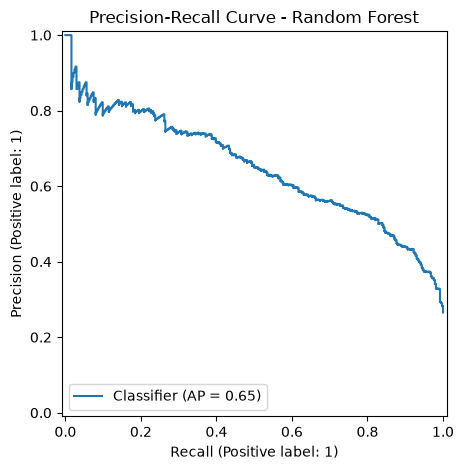

In [28]:
plt.figure(figsize=(7, 5))

PrecisionRecallDisplay.from_predictions(
    y_test,
    final_probabilities
)

plt.title("Precision-Recall Curve - Random Forest")
plt.tight_layout()
plt.show()


15. Feature Importance

Feature importance helps identify which variables contribute most to the Random Forest model's predictions. This provides a more interpretable view of the factors associated with customer churn.

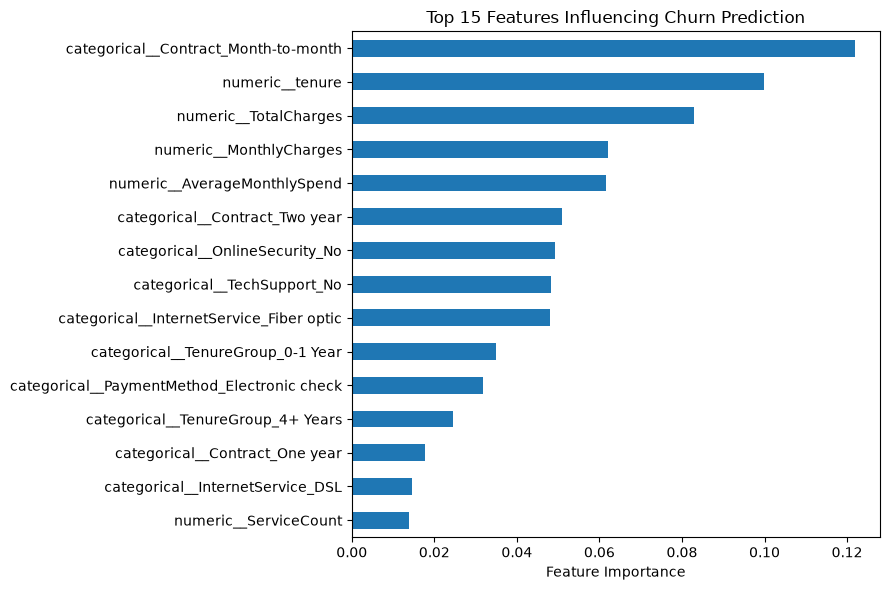

In [29]:
model = final_model.named_steps["model"]

feature_names = (
    final_model
    .named_steps["preprocessing"]
    .get_feature_names_out()
)

importance = pd.Series(
    model.feature_importances_,
    index=feature_names
)

top_features = (
    importance
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(9, 6))

top_features.sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Features Influencing Churn Prediction")
plt.xlabel("Feature Importance")

plt.tight_layout()
plt.show()


In [30]:
import joblib

joblib.dump(
    final_model,
    "../models/churn_model.pkl"
)

print("Model saved successfully.")


Model saved successfully.


16. Conclusion

This project developed a machine learning approach for predicting customer churn using the Telco customer dataset.

The dataset contained 7,043 customer records and included demographic information, service details, contract information, and billing information. During data preparation, the TotalCharges column was converted from text to numeric format, and 11 missing values were identified and handled.

Three classification models were compared: Logistic Regression, Random Forest, and XGBoost. The models showed different strengths across accuracy, precision, recall, F1-score, and ROC-AUC.

Random Forest was selected for the final analysis because it provided the best balance between precision, recall, and F1-score among the initial models. At the default probability threshold of 0.50, the model correctly identified 288 customers who churned, while missing 86 actual churners.

The results demonstrate that machine learning can be used to identify customers who may be at risk of churn. In a real business environment, these predictions could support customer retention strategies by helping the company focus its efforts on customers with a higher likelihood of leaving.